In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background') 
import scipy.constants as constants
import scipy.stats as stats
import pandas as pd
N, D = 10000, 3 
rand = stats.uniform(-25000, 50000) #half the diameter of the milky eay
samp = rand.rvs(D*N).reshape(D, -1)
x, y, z = samp
r = np.sqrt(np.sum(samp**2, axis=0)) #quicker way to get sum of squares
r_m = r*constants.light_year #this was kept because I preferred the orders of magnitude this way
S = (3.333*(10**29)) / (4*np.pi*(r_m**2)) 
df = pd.DataFrame()
df['Radius'] = r
df['Flux'] = S
sorted_df = df.sort_values(by = 'Flux', ascending = False) #this puts the row with the smallest flux at the very top
sorted_df.reset_index(inplace = True) #the problem then was that if I called index it would do the one I sought to remove, so I dropped it
sorted_df.drop(columns='index')

: 

we know that flux is inversely proportional to the square of its distance(radius) cause of the formula used in line 13. and that N is proportional to the radius cubed. 
So we then know that with it combined, N is proportional to S^(-3/2).
Making that log means that the -3/2 pops in front of the log, becoming the slope

In [24]:
S_prop_r = S**(-1/2)
S_prop_N = S_prop_r**3
np.log(S_prop_N) / np.log(S)

array([-1.5, -1.5, -1.5, ..., -1.5, -1.5, -1.5], shape=(10000,))

In [14]:
distro_df = pd.DataFrame()
logN = np.log(sorted_df.index)
logS = np.log(sorted_df.Flux)
distro_df['logN'] = logN
distro_df['logS'] = logS
distro_df.drop(0) #dropped -inf because it was messing with calculations

/home/bean625/miniconda3/lib/python3.13/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)


,logN,logS
1,0.000000,-22.562594
2,0.693147,-22.863807
3,1.098612,-23.114625
4,1.386294,-23.155375
5,1.609438,-23.564580
...,...,...
9995,9.209840,-29.360641
9996,9.209940,-29.360901
9997,9.210040,-29.361542
9998,9.210140,-29.380061


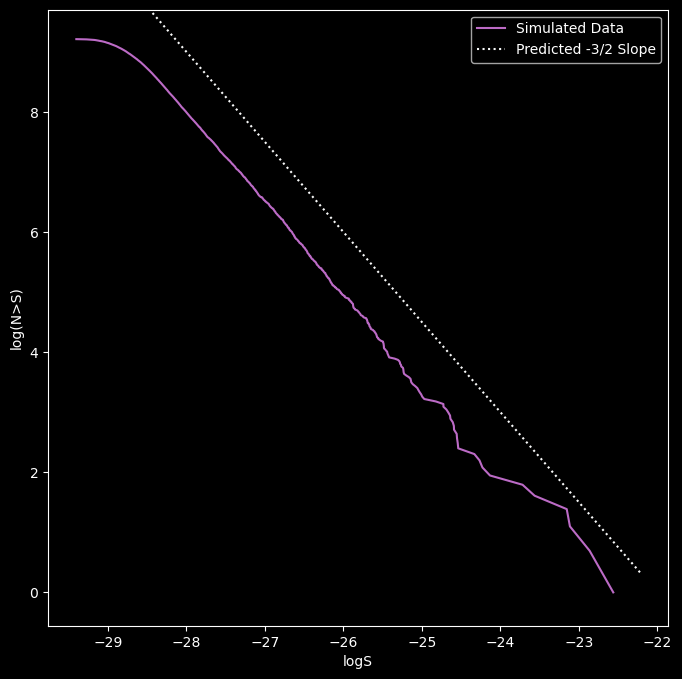

In [18]:
x = distro_df.logS
y = distro_df.logN
known_line = -1.5*x - 33 #the slope should be -1.5x, but the intercept varies based on where it started. so I did my best to overlay
fig = plt.figure(figsize=[8,8])
ax1 = plt.subplot(111)
ax1.plot(x,y, c = "#BC6BC6FF", label='Simulated Data')
ax1.set(xlabel='logS', ylabel='log(N>S)')
ax1.plot(x, known_line, c = "#F9FAFA", linestyle= 'dotted', label='Predicted -3/2 Slope')
ax1.set_ylim(ymax=9.7)
plt.legend()

In [51]:
print (f'The line of best fit is: {np.round(m, decimals=4)}x - {np.abs(np.round(b, decimals = 4))}') 
#abs because I didn't like the negative so close

The line of best fit is: nanx - nan
